<div align='center'>
<h1 style='font-size:38px;'>Computing Thermal & Scattered Fluxes</h1>
<h2 style='font-weight:400;'>Using <code>Fluxes</code> and <code>Fluxes_optimized</code></h2>
<p><em>Size integration, wavelength loops, and performance comparison</em></p>
</div>

---
**Contents:**
1. Imports + objects
2. Instantiate Fluxes classes
3. Compute scattered flux
4. Compute thermal flux
5. Plot radial dependence per wavelength
6. Fit power-law slopes
7. Compare optimized vs original timing
8. Notes

## 1. Imports and setup

In [ ]:
from pyGrater import Star, Grain, Fluxes


from pyGrater.size_distributions import power_law_distribution
from pyGrater.phase_functions import isotropic

import numpy as np
import matplotlib.pyplot as plt
import time

INFO - Logging to file: /Users/prioletp/PhD/public_codes/pyGrater/logs/pyGrater_20260625_182639.log (logging_config.py:line 152)


CREATING GRAIN OBJECT
Developper parameters file: /Users/prioletp/PhD/public_codes/pyGrater/pyGrater/parameters/developper_params.yaml
Grain composition: astroSi
astroSi optical tables already exist :
--> Wavelengths : 1000 values from 5.0e-02 to 2.0e+03 microns
--> Sizes : 600 values from 1.0e-02 to 3.0e+03 microns
CREATING STAR OBJECT
Star properties file: /Users/prioletp/PhD/public_codes/pyGrater/data/star_data/stars_main_properties.txt
Star name: 'HD113766'
The temperature is 6650.0 K
The logg is 4.02 cgs
The radius is 1.35 R_sun
The distance is 108.63 pc
The spectral type is F5
The normalization band is V
The apparent magnitude in V band is 8.08 mag
The stellar spectrum is binned by a factor of 20
The closest spectrum in the grid has T_eff = 6600.0 K and log(g) = 4.0 cgs
Stellar spectrum loaded and normalized.
CREATING TEMPERATURE OBJECT for the grain temperature calculations.
Loading the thermal distance array from file: temperatures_astroSi_Tsub1500.0_starHD113766.npz
{'a_min': 

## 2. Grain, Star, and wavelength grid

<ul>
  <li>Create the `Grain` object and the `Star` object.</li>
  <li>Set the wavelengths for the calculation of the optical properties.</li>
</ul>



In [2]:
grain = Grain(redo_Q=False, composition='astroSi')
star = Star(star_name='HD113766')
wavelengths_for_calc = np.array([0.55, 1.65, 10.257, 60.0, 160.0, 850.0])  # microns


## 3. Instantiate Fluxes implementations

In [3]:
flux_obj = Fluxes(grain, star, wavelengths_for_calc, size_distribution_function=power_law_distribution, scattering_phase_function=isotropic)


## 4. Define parameters of size distribution

In [4]:
params = dict(a_min=0.01e-6, a_max=3000e-6, kappa=3.5, N_sizes_integral=300)
print(params)

## 5. Compute scattered flux


In [5]:
t0 = time.time()
flux_scattered = flux_obj.scattered_flux(params)
t_orig_sc = time.time()-t0
print(f'Scattered time: {t_orig_sc:.2f}s ')

print('Scattered flux shape:', flux_scattered.shape , '->', '(wavelengths, distances,  scattering angles (by default 500))')

## 6. Compute thermal flux


In [6]:
t0 = time.time()
flux_thermal = flux_obj.thermal_flux(params)
t_orig_th = time.time()-t0

print(f'Thermal time: {t_orig_th:.2f}s')

## 7. Plot radial dependence for each wavelength


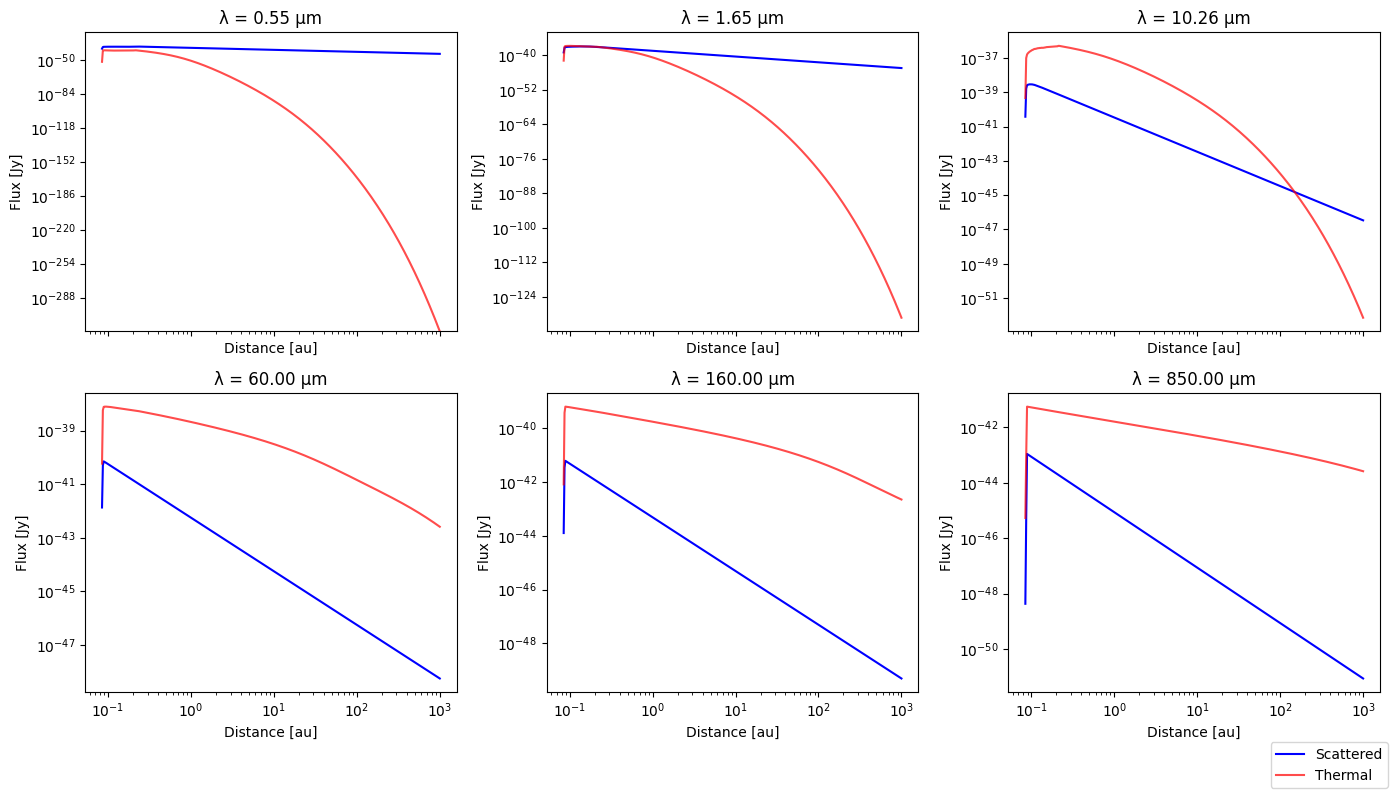

In [7]:
dist = flux_obj.stellocentric_distances_au
colors = plt.cm.viridis(np.linspace(0,1,len(wavelengths_for_calc)))
fig, axes = plt.subplots(2,3, figsize=(14,8), sharex=True)
axes = axes.flatten()
for i, wl in enumerate(wavelengths_for_calc):
    ax = axes[i]
    ax.loglog(dist, flux_scattered[i, :, 0], c='blue')
    ax.loglog(dist, flux_thermal[i], c='red', alpha=0.7)
    ax.set_title(f'λ = {wl:.2f} µm')
    ax.set_xlabel('Distance [au]')
    ax.set_ylabel('Flux [Jy]')
for j in range(len(wavelengths_for_calc), len(axes)):
    fig.delaxes(axes[j])
# Single legend outside axes, bottom right of figure
from matplotlib.lines import Line2D
legend_handles = [Line2D([0], [0], color='blue', label='Scattered'),
                  Line2D([0], [0], color='red', alpha=0.7, label='Thermal')]
fig.legend(handles=legend_handles, loc='lower right', bbox_to_anchor=(1.0, 0.0),
           bbox_transform=fig.transFigure, fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 1])

## 8. Power-law slope fitting (flux ∝ r^p)

In [8]:
def fit_power_law(r, f):
    mask = r > 0.1
    log_r = np.log10(r[mask])
    log_f = np.log10(f[mask])
    return np.polyfit(log_r, log_f, 1)[0]
slopes_sc = []
slopes_th = []
print(flux_scattered.shape)
print(flux_thermal.shape)
for i in range(len(wavelengths_for_calc)):
    slopes_sc.append(fit_power_law(dist, flux_scattered[i, :, 0]))
    slopes_th.append(fit_power_law(dist, flux_thermal[i]))

for wl, ps, pt in zip(wavelengths_for_calc, slopes_sc, slopes_th):
    print(f'λ={wl:.2f}µm  scattered p={ps:.2f}  thermal p={pt:.2f}')

## 10. Notes
- Integration uses trapezoid over grain size distribution.
- Adjust resolution via `N_sizes_integral`, wavelength list, or thermal grid `N_temp` in `Temperatures`.